In [1]:
!pip install pennylane -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 74.2 MB/s eta 0:00:00


In [2]:
import pennylane as qml
import torch
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

In [3]:
data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)
print(y.shape)
print(data.feature_names)

(569, 30)
(569,)
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [4]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.2,
    random_state=42,
    stratify=y_train_val
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=5)

X_train = pca.fit_transform(X_train_scaled)
X_val = pca.transform(X_val_scaled)
X_test = pca.transform(X_test_scaled)

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Training shape: (364, 5)
Validation shape: (91, 5)
Test shape: (114, 5)


In [5]:
qsvt_scaler = MinMaxScaler(
    feature_range=(-0.95, 0.95)
)

X_train_final = qsvt_scaler.fit_transform(
    X_train
)

X_val_final = qsvt_scaler.transform(
    X_val
)

X_test_final = qsvt_scaler.transform(
    X_test
)


In [6]:
X_train = torch.tensor(
    X_train_final,
    dtype=torch.float64
)

X_val = torch.tensor(
    X_val_final,
    dtype=torch.float64
)

X_test = torch.tensor(
    X_test_final,
    dtype=torch.float64
)

y_train = torch.tensor(
    y_train,
    dtype=torch.float64
)

y_val = torch.tensor(
    y_val,
    dtype=torch.float64
)

y_test = torch.tensor(
    y_test,
    dtype=torch.float64
)


In [7]:
# Explicit model and evaluation configuration
n_features = X_train.shape[1]
n_phases = 4  # 4 phase projectors give a degree-3 QSVT sequence
decision_threshold = 0.5

torch.manual_seed(0)

hidden_nodes = 6

# Layer 1: 5 inputs → 6 hidden nodes
hidden_phases = torch.nn.Parameter(
    0.1 * torch.randn(
        hidden_nodes,
        n_features,
        n_phases,
        dtype=torch.float64
    )
)

hidden_weights = torch.nn.Parameter(
    torch.randn(
        hidden_nodes,
        n_features,
        dtype=torch.float64
    ) / np.sqrt(n_features)
)

hidden_bias = torch.nn.Parameter(
    torch.zeros(
        hidden_nodes,
        dtype=torch.float64
    )
)

# Layer 2: 6 hidden nodes → 1 output
output_phases = torch.nn.Parameter(
    0.1 * torch.randn(
        hidden_nodes,
        n_phases,
        dtype=torch.float64
    )
)

output_weights = torch.nn.Parameter(
    torch.randn(
        hidden_nodes,
        dtype=torch.float64
    ) / np.sqrt(hidden_nodes)
)

output_bias = torch.nn.Parameter(
    torch.zeros(
        1,
        dtype=torch.float64
    )
)

In [8]:
dev = qml.device(
    "default.qubit",
    wires=1
)


@qml.qnode(
    dev,
    interface="torch",
    diff_method="backprop"
)
def quantum_edge(x, edge_phases):

    # Protect arccos from invalid numerical inputs
    safe_x = torch.clamp(
        x,
        -0.999999,
        0.999999
    )

    # Top-left element of RX is x
    block_encoding = qml.RX(
        2 * torch.arccos(safe_x),
        wires=0
    )

    projectors = [
        qml.PCPhase(
            edge_phases[k],
            dim=1,
            wires=0
        )
        for k in range(
            len(edge_phases)
        )
    ]

    qml.QSVT(
        block_encoding,
        projectors
    )

    return qml.state()

In [9]:
def edge_output(x, edge_phases):

    state = quantum_edge(
        x,
        edge_phases
    )

    return torch.real(
        state[0]
    )

In [10]:
def first_qkan_layer(sample):

    hidden_values = []

    for k in range(hidden_nodes):

        node_total = hidden_bias[k]

        for j in range(n_features):

            quantum_value = edge_output(
                sample[j],
                hidden_phases[k, j]
            )

            node_total = node_total + (
                hidden_weights[k, j]
                * quantum_value
            )

        # The second QSVT layer requires inputs in [-1, 1]
        bounded_value = torch.tanh(
            node_total
        )

        hidden_values.append(
            bounded_value
        )

    return torch.stack(
        hidden_values
    )

In [11]:
def qkan_logit(sample):

    hidden_values = first_qkan_layer(
        sample
    )

    logit = output_bias[0]

    for k in range(hidden_nodes):

        quantum_value = edge_output(
            hidden_values[k],
            output_phases[k]
        )

        logit = logit + (
            output_weights[k]
            * quantum_value
        )

    return logit


def qkan_predict_proba(sample):

    logit = qkan_logit(
        sample
    )

    return torch.sigmoid(
        logit
    )

In [12]:
sample = X_train[0]

hidden_test = first_qkan_layer(
    sample
)

logit_test = qkan_logit(
    sample
)

probability_test = torch.sigmoid(
    logit_test
)

print("Hidden values:", hidden_test)
print("Hidden shape:", hidden_test.shape)
print("Logit:", logit_test)
print("Probability:", probability_test)

print(
    "All values finite:",
    torch.isfinite(logit_test).item()
)

Hidden values: tensor([ 0.0533, -0.1958, -0.3634,  0.2198,  0.0070,  0.0318],
       dtype=torch.float64, grad_fn=<StackBackward0>)
Hidden shape: torch.Size([6])
Logit: tensor(-0.0528, dtype=torch.float64, grad_fn=<AddBackward0>)
Probability: tensor(0.4868, dtype=torch.float64, grad_fn=<SigmoidBackward0>)
All values finite: True


In [13]:
parameters = [
    hidden_phases,
    hidden_weights,
    hidden_bias,
    output_phases,
    output_weights,
    output_bias
]

optimizer = torch.optim.AdamW(
    parameters,
    lr=0.005,
    weight_decay=1e-4
)

criterion = torch.nn.BCEWithLogitsLoss()

In [14]:
max_epochs = 50
batch_size = 16
patience = 10

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_parameters = None
epochs_without_improvement = 0

for epoch in range(max_epochs):

    permutation = torch.randperm(
        X_train.shape[0]
    )

    epoch_loss = 0.0

    for start in range(
        0,
        X_train.shape[0],
        batch_size
    ):

        indices = permutation[
            start:start + batch_size
        ]

        X_batch = X_train[indices]
        y_batch = y_train[indices]

        optimizer.zero_grad()

        # Raw logits: no sigmoid here
        logits = torch.stack([
            qkan_logit(sample)
            for sample in X_batch
        ])

        loss = criterion(
            logits,
            y_batch
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            parameters,
            max_norm=5.0
        )

        optimizer.step()

        epoch_loss += (
            loss.item()
            * X_batch.shape[0]
        )

    average_train_loss = (
        epoch_loss
        / X_train.shape[0]
    )

    train_losses.append(
        average_train_loss
    )

    with torch.no_grad():

        val_logits = torch.stack([
            qkan_logit(sample)
            for sample in X_val
        ])

        val_loss = criterion(
            val_logits,
            y_val
        )

        current_val_loss = val_loss.item()

    val_losses.append(
        current_val_loss
    )

    print(
        f"Epoch {epoch + 1:03d} | "
        f"Train Loss = {average_train_loss:.4f} | "
        f"Validation Loss = {current_val_loss:.4f}"
    )

    if current_val_loss < best_val_loss - 1e-4:

        best_val_loss = current_val_loss

        best_parameters = [
            parameter.detach().clone()
            for parameter in parameters
        ]

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:

        print(
            f"Early stopping at epoch "
            f"{epoch + 1}"
        )

        break

Epoch 001 | Train Loss = 0.6118 | Validation Loss = 0.5755
Epoch 002 | Train Loss = 0.5245 | Validation Loss = 0.4935
Epoch 003 | Train Loss = 0.4174 | Validation Loss = 0.3859
Epoch 004 | Train Loss = 0.2995 | Validation Loss = 0.2899
Epoch 005 | Train Loss = 0.2132 | Validation Loss = 0.2240
Epoch 006 | Train Loss = 0.1625 | Validation Loss = 0.1836
Epoch 007 | Train Loss = 0.1315 | Validation Loss = 0.1543
Epoch 008 | Train Loss = 0.1141 | Validation Loss = 0.1358
Epoch 009 | Train Loss = 0.1007 | Validation Loss = 0.1223
Epoch 010 | Train Loss = 0.0907 | Validation Loss = 0.1125
Epoch 011 | Train Loss = 0.0896 | Validation Loss = 0.1051
Epoch 012 | Train Loss = 0.0812 | Validation Loss = 0.0983
Epoch 013 | Train Loss = 0.0759 | Validation Loss = 0.0967
Epoch 014 | Train Loss = 0.0783 | Validation Loss = 0.0917
Epoch 015 | Train Loss = 0.0710 | Validation Loss = 0.0870
Epoch 016 | Train Loss = 0.0692 | Validation Loss = 0.0847
Epoch 017 | Train Loss = 0.0666 | Validation Loss = 0.08

KeyboardInterrupt: 

In [15]:
if best_parameters is not None:

    with torch.no_grad():

        for parameter, best_value in zip(
            parameters,
            best_parameters
        ):

            parameter.copy_(
                best_value
            )

print(
    "Best validation loss:",
    best_val_loss
)

Best validation loss: 0.0697074122965941


In [16]:
import matplotlib.pyplot as plt

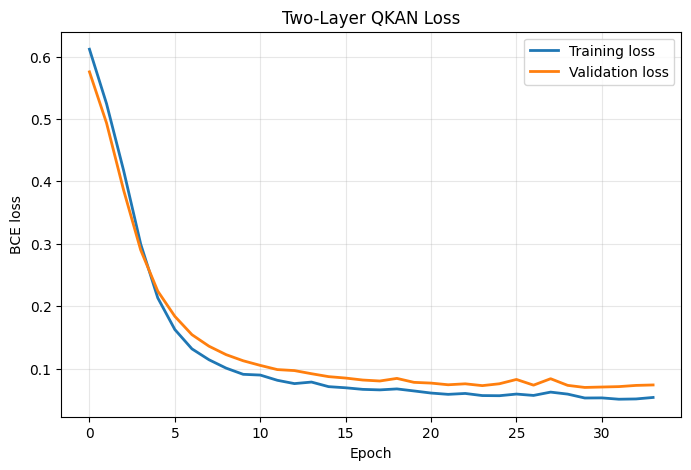

In [17]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    train_losses,
    label="Training loss",
    linewidth=2
)

plt.plot(
    val_losses,
    label="Validation loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("Two-Layer QKAN Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [19]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

In [20]:
with torch.no_grad():

    test_logits = torch.stack([
        qkan_logit(sample)
        for sample in X_test
    ])

    test_probabilities = torch.sigmoid(
        test_logits
    )

test_predictions = (
    test_probabilities >= decision_threshold
).long()

y_test_numpy = y_test.numpy()
test_predictions_numpy = test_predictions.numpy()
test_probabilities_numpy = test_probabilities.numpy()

test_accuracy = accuracy_score(
    y_test_numpy,
    test_predictions_numpy
)

test_auc = roc_auc_score(
    y_test_numpy,
    test_probabilities_numpy
)

print(
    "Threshold:",
    round(decision_threshold, 2)
)

print(
    "Test accuracy:",
    round(test_accuracy, 4)
)

print(
    "ROC-AUC:",
    round(test_auc, 4)
)

print()

print(
    classification_report(
        y_test_numpy,
        test_predictions_numpy,
        target_names=[
            "Malignant",
            "Benign"
        ],
        digits=4
    )
)

Threshold: 0.5
Test accuracy: 0.9561
ROC-AUC: 0.9907

              precision    recall  f1-score   support

   Malignant     0.9302    0.9524    0.9412        42
      Benign     0.9718    0.9583    0.9650        72

    accuracy                         0.9561       114
   macro avg     0.9510    0.9554    0.9531       114
weighted avg     0.9565    0.9561    0.9562       114

